# Logistic regression: human-designed features for friendship prediction

**Research question this notebook serves:** *Can learned representations of social interactions outperform manually engineered behavioral features for friendship prediction?*

This notebook builds the **human-designed-features** arm of that comparison. `nn.ipynb` builds the counterpart **learned-representations** arm (Node2Vec graph embeddings feeding MLP / XGBoost classifiers on the SMS, calls, and proximity graphs). Both arms predict the same label — `is_fb_friend` — from the same four weeks of Copenhagen Networks Study interaction data, so their held-out performance is directly comparable.

A second thing this notebook produces, useful for the interpretability sub-question ("which forms of interaction best reveal meaningful relationships?"), is a **logistic regression coefficient table** — the model-coefficient flavor of feature importance. This is a natural counterpart to whatever feature-importance / ablation numbers come out of the tree-based and embedding models.

*Note: this notebook explains the data pipeline, leakage-avoidance choices, and how to read the results. The conceptual explanation of how logistic regression itself works (the sigmoid, log-odds, maximum likelihood, etc.) is intentionally left out — that part of the presentation is being written separately.*

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

PAIR_KEYS = ['user_a', 'user_b']
RANDOM_STATE = 42

cwd = Path.cwd()
if (cwd / 'FinalProject' / 'data' / 'processed').exists():
    PROJECT_DIR = cwd / 'FinalProject'
elif (cwd / 'data' / 'processed').exists():
    PROJECT_DIR = cwd
elif (cwd.parent / 'data' / 'processed').exists():
    PROJECT_DIR = cwd.parent
else:
    raise FileNotFoundError('Could not locate FinalProject/data/processed.')

DATA_DIR = PROJECT_DIR / 'data' / 'processed'
FIGURE_DIR = PROJECT_DIR / 'website_assets' / 'eda'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

BLUE, ORANGE, GREEN, VIOLET = '#2A78D6', '#EB6834', '#1BAF7A', '#4A3AA7'
GREY, LIGHT_GREY, INK = '#8A8984', '#E6E5DF', '#171717'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white', 'figure.dpi': 110})

def save_figure(fig, filename):
    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=180, bbox_inches='tight', facecolor='white')
    print(f'Saved: {path}')

## 1. Load the prepared model inputs

Rather than re-deriving features from raw interaction logs here, this notebook reads the outputs of the feature-engineering pipeline (`csvMerge.ipynb`) together with the manifests that document *what every column means, whether it's safe to use, and how it should be transformed*. Building the model straight from those manifests (instead of hardcoding a feature list) means the modeling step stays honest about the same leakage rules the feature-engineering step already worked out.

Two model-input tables are provided, and we use both:

- **`logistic_baseline_input.csv`** — all 27 eligible features, including five *general activity controls* (e.g. total texts sent, calls received per day). These were computed from the **full population**, not recomputed per fold, so they carry a small amount of leakage risk across the train/test boundary (flagged as `requires_outer_fold_recompute` in the manifest).
- **`logistic_strict_inductive_input.csv`** — the 22 features that remain after dropping every column that isn't safe under strict participant-disjoint evaluation. This is the leakage-conservative version.

We fit and evaluate both, and treat the gap between them as a diagnostic: if the baseline model meaningfully outperforms the strict-inductive model, that gap is at least partly inflated performance from the leakage-prone controls, not real signal.

In [2]:
baseline_df = pd.read_csv(DATA_DIR / 'logistic_baseline_input.csv')
strict_df = pd.read_csv(DATA_DIR / 'logistic_strict_inductive_input.csv')
manifest = pd.read_csv(DATA_DIR / 'model_feature_manifest.csv')
exclusions = pd.read_csv(DATA_DIR / 'model_exclusion_manifest.csv')
folds = pd.read_csv(DATA_DIR / 'participant_disjoint_folds.csv')

for df in (baseline_df, strict_df):
    if df['is_fb_friend'].dtype == object:
        df['is_fb_friend'] = df['is_fb_friend'].map({'True': True, 'False': False})
    df['is_fb_friend'] = df['is_fb_friend'].astype(bool)
    assert not df[PAIR_KEYS].duplicated().any()
    assert df['user_a'].lt(df['user_b']).all()

fold_map = dict(zip(folds['user'], folds['participant_fold']))
n_folds = folds['participant_fold'].nunique()

print(f'Baseline input:         {len(baseline_df):,} pairs, {baseline_df.shape[1] - 3} features')
print(f'Strict-inductive input: {len(strict_df):,} pairs, {strict_df.shape[1] - 3} features')
print(f'Friend prevalence (baseline table): {baseline_df["is_fb_friend"].mean():.2%}')
print(f'Participant folds: {n_folds} disjoint folds covering {folds.shape[0]:,} participants')

Baseline input:         79,692 pairs, 27 features
Strict-inductive input: 79,692 pairs, 22 features
Friend prevalence (baseline table): 4.09%
Participant folds: 5 disjoint folds covering 742 participants


## 2. Why the features are excluded that are excluded

Before picking a feature list by hand, it's worth looking at what the feature-engineering pass already ruled out and why. These are exact duplicates, derived-from-the-label columns, identifiers, or fields that are undefined for part of the population — keeping them would either leak the label back into the model or silently double-count a signal.

In [3]:
display(exclusions)

,column,reason
0,user_a,identifier; split key only
1,user_b,identifier; split key only
2,is_fb_friend,target
3,behavior_candidate,"population filter, not a behavioral strength f..."
4,behavior_roster_pair,population filter for the label-independent al...
5,has_any_pair_interaction,constant inside the primary behavior-candidate...
6,user_a_daily_texts_received,endpoint component; use the symmetric combined...
7,user_b_daily_texts_received,endpoint component; use the symmetric combined...
8,mutual_friends,derived from the outcome graph unless rebuilt ...
9,total_facebook_friend_count,derived from the outcome graph


## 3. Fold-local preprocessing, driven by the manifest

Two rules that matter for a dataset like this:

1. **Skewed count features need `log1p`.** Contact minutes, text counts, call counts, and streak lengths are heavily right-skewed — a handful of very active pairs would otherwise dominate the scaled feature. `log1p` compresses that without breaking at zero.
2. **Imputation and scaling must be *fold-local*.** Several features (proximity RSSI, reciprocity, call duration) are only defined when a pair actually interacted, so they're missing for pairs that never called or never came within Bluetooth range. Filling those gaps with the population median, or fitting a `StandardScaler` on the full dataset, would leak test-fold statistics into the training fold. Instead, the median and the scaler are fit **only on the current fold's training pairs**, then applied to that fold's held-out pairs.

The `future_transform` column in the manifest already specifies which of these steps each feature needs, so the preprocessing function below reads that instead of hardcoding a feature list — if the feature-engineering notebook adds or reclassifies a column, this modeling step picks it up automatically.

In [4]:
def parse_transform_spec(text):
    text = text.lower()
    return {
        'impute': 'imputation' in text,
        'log1p': 'log1p' in text,
        'scale': 'scaling' in text,
    }

primary_features = (
    manifest[manifest['eligible_for_primary_model']]
    .sort_values('primary_model_order')
    .reset_index(drop=True)
)
FEATURE_SPECS = {row.column: parse_transform_spec(row.future_transform) for row in primary_features.itertuples()}

STRICT_COLUMNS = [c for c in primary_features['column'] if primary_features.set_index('column').loc[c, 'safe_for_strict_inductive_as_exported']]
BASELINE_COLUMNS = list(primary_features['column'])

print(f'{len(STRICT_COLUMNS)} strict-inductive features, {len(BASELINE_COLUMNS)} baseline features')
display(primary_features[['column', 'role', 'future_transform', 'safe_for_strict_inductive_as_exported']])

22 strict-inductive features, 27 baseline features


,column,role,future_transform,safe_for_strict_inductive_as_exported
0,in_person_contact_minutes,direct pair evidence,log1p + fold-local scaling,True
1,average_proximity_rssi,direct pair evidence,fold-local imputation + scaling,True
2,proximity_measurements,direct pair evidence,log1p + fold-local scaling,True
3,has_proximity_measurement,direct pair evidence,binary; no scaling,True
4,fraction_rssi_above_threshold,direct pair evidence,fold-local imputation + scaling,True
5,texts_shared,direct pair evidence,log1p + fold-local scaling,True
6,has_text_exchange,direct pair evidence,binary; no scaling,True
7,days_texted,direct pair evidence,log1p + fold-local scaling,True
8,text_reciprocity,direct pair evidence,fold-local imputation + scaling,True
9,total_calls,direct pair evidence,log1p + fold-local scaling,True


In [5]:
def fit_transform_fold(train_frame, test_frame, columns, specs, clip_z=5.0):
    """Fit imputation/scaling on the training fold only; apply to both folds."""
    train_X = train_frame[columns].copy()
    test_X = test_frame[columns].copy()

    for column in columns:
        spec = specs[column]
        if spec['impute']:
            median = train_X[column].median()
            train_X[column] = train_X[column].fillna(median)
            test_X[column] = test_X[column].fillna(median)
        if spec['log1p']:
            train_X[column] = np.log1p(train_X[column].clip(lower=0))
            test_X[column] = np.log1p(test_X[column].clip(lower=0))

    scale_columns = [c for c in columns if specs[c]['scale']]
    if scale_columns:
        scaler = StandardScaler()
        train_X[scale_columns] = scaler.fit_transform(train_X[scale_columns])
        test_X[scale_columns] = scaler.transform(test_X[scale_columns])
        # A handful of features (e.g. reciprocity) are only defined for well under 1%
        # of pairs. After fold-local median imputation almost every row is identical,
        # so the tiny leftover variance from the few real values inflates their
        # standardized scores to 30-40+ std deviations. That doesn't throw an error,
        # but it destabilizes the solver (matmul overflow warnings while fitting) and
        # gives a handful of rows outsized leverage. Clipping to +/-5 std keeps the
        # ranking information while removing the pathological leverage.
        train_X[scale_columns] = train_X[scale_columns].clip(lower=-clip_z, upper=clip_z)
        test_X[scale_columns] = test_X[scale_columns].clip(lower=-clip_z, upper=clip_z)

    return train_X, test_X

## 4. Participant-disjoint cross-validation

A random 80/20 split over **pairs** can put the same participant in both the training and test sets (e.g. `(3, 7)` in training, `(3, 91)` in testing) — the model can then partly identify person 3 rather than learn a general interaction pattern, and performance looks better than it would on genuinely new people.

`participant_disjoint_folds.csv` assigns every participant to exactly one of five folds. For each outer fold *k*:

- **Test set:** pairs where *both* participants are in fold *k*.
- **Train set:** pairs where *neither* participant is in fold *k*.
- **Dropped:** pairs that straddle the boundary (one participant in fold *k*, the other not) — these are excluded from both sides for that fold, since they're neither a clean train example nor a clean test example.

Rotating *k* through all five folds gives five honest train/test splits from a single, fixed, reproducible partition — no repeated random resampling required, and every participant serves as a held-out test subject exactly once.

In [6]:
def fold_masks(df, k):
    a_fold = df['user_a'].map(fold_map)
    b_fold = df['user_b'].map(fold_map)
    train_mask = (a_fold != k) & (b_fold != k)
    test_mask = (a_fold == k) & (b_fold == k)
    return train_mask, test_mask

for k in range(n_folds):
    train_mask, test_mask = fold_masks(strict_df, k)
    dropped = len(strict_df) - train_mask.sum() - test_mask.sum()
    print(f'Fold {k}: {train_mask.sum():,} train pairs, {test_mask.sum():,} test pairs, {dropped:,} boundary pairs dropped')

Fold 0: 50,728 train pairs, 3,261 test pairs, 25,703 boundary pairs dropped
Fold 1: 50,926 train pairs, 3,169 test pairs, 25,597 boundary pairs dropped
Fold 2: 51,123 train pairs, 3,185 test pairs, 25,384 boundary pairs dropped
Fold 3: 51,546 train pairs, 2,962 test pairs, 25,184 boundary pairs dropped
Fold 4: 50,542 train pairs, 3,212 test pairs, 25,938 boundary pairs dropped


## 5. Cross-validated performance: strict-inductive vs. baseline

For each of the five outer folds, and for both feature sets, we fit `LogisticRegression(class_weight='balanced')` on the fold's training pairs and score it on that fold's held-out pairs. `class_weight='balanced'` matters here because friendship is rare relative to all possible pairs — without it, the model could get a deceptively low loss by predicting "not friends" for almost everyone.

Two metrics, because either alone can mislead on an imbalanced label:

- **ROC-AUC** — probability a random friend pair is ranked above a random non-friend pair. 0.50 is random ranking.
- **Average precision (AP)** — area under the precision-recall curve. Its random baseline is the friend prevalence itself (not 0.50), so we report the **lift over that baseline** as the more interpretable number.

In [7]:
def run_cv(df, columns, label):
    rows = []
    for k in range(n_folds):
        train_mask, test_mask = fold_masks(df, k)
        train_frame, test_frame = df.loc[train_mask], df.loc[test_mask]

        train_X, test_X = fit_transform_fold(train_frame, test_frame, columns, FEATURE_SPECS)
        y_train = train_frame['is_fb_friend'].astype(int)
        y_test = test_frame['is_fb_friend'].astype(int)

        model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
        model.fit(train_X, y_train)
        proba = model.predict_proba(test_X)[:, 1]

        rows.append({
            'Feature set': label,
            'Fold': k,
            'Test prevalence': y_test.mean(),
            'ROC-AUC': roc_auc_score(y_test, proba),
            'Average precision': average_precision_score(y_test, proba),
        })
    return pd.DataFrame(rows)

strict_results = run_cv(strict_df, STRICT_COLUMNS, 'Strict-inductive (22 features)')
baseline_results = run_cv(baseline_df, BASELINE_COLUMNS, 'Baseline (27 features)')
cv_results = pd.concat([strict_results, baseline_results], ignore_index=True)

cv_summary = (
    cv_results.groupby('Feature set')
    .agg(
        Friend_prevalence=('Test prevalence', 'mean'),
        ROC_AUC=('ROC-AUC', 'mean'),
        ROC_AUC_std=('ROC-AUC', 'std'),
        Average_precision=('Average precision', 'mean'),
        AP_std=('Average precision', 'std'),
    )
    .reset_index()
)
cv_summary['AP lift over baseline prevalence'] = cv_summary['Average_precision'] / cv_summary['Friend_prevalence']

display(
    cv_summary.style.format({
        'Friend_prevalence': '{:.2%}', 'ROC_AUC': '{:.3f}', 'ROC_AUC_std': '{:.3f}',
        'Average_precision': '{:.3f}', 'AP_std': '{:.3f}', 'AP lift over baseline prevalence': '{:.2f}×',
    }).hide(axis='index').set_caption('Mean performance across five participant-disjoint outer folds')
)

Feature set,Friend_prevalence,ROC_AUC,ROC_AUC_std,Average_precision,AP_std,AP lift over baseline prevalence
Baseline (27 features),4.17%,0.843,0.026,0.480,0.025,11.52×
Strict-inductive (22 features),4.17%,0.838,0.023,0.480,0.027,11.50×


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_cv_performance.png


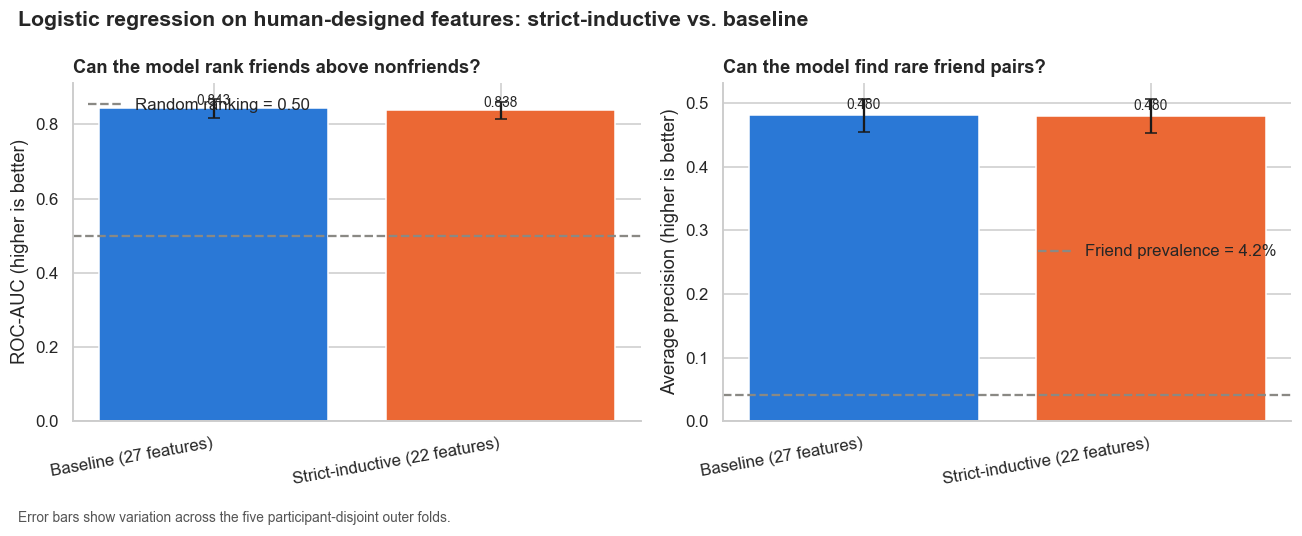

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
colors = [BLUE, ORANGE]
x = np.arange(len(cv_summary))

axes[0].bar(x, cv_summary['ROC_AUC'], yerr=cv_summary['ROC_AUC_std'], color=colors, capsize=4)
axes[0].axhline(0.5, color=GREY, linestyle='--', label='Random ranking = 0.50')
axes[0].set_ylabel('ROC-AUC (higher is better)')
axes[0].set_title('Can the model rank friends above nonfriends?', loc='left', fontweight='bold')
axes[0].legend(frameon=False, loc='upper left')

axes[1].bar(x, cv_summary['Average_precision'], yerr=cv_summary['AP_std'], color=colors, capsize=4)
baseline_rate = cv_summary['Friend_prevalence'].mean()
axes[1].axhline(baseline_rate, color=GREY, linestyle='--', label=f'Friend prevalence = {baseline_rate:.1%}')
axes[1].set_ylabel('Average precision (higher is better)')
axes[1].set_title('Can the model find rare friend pairs?', loc='left', fontweight='bold')
axes[1].legend(frameon=False)

for ax, values in [(axes[0], cv_summary['ROC_AUC']), (axes[1], cv_summary['Average_precision'])]:
    ax.set_xticks(x, cv_summary['Feature set'], rotation=10, ha='right')
    for index, value in enumerate(values):
        ax.text(index, value + 0.01, f'{value:.3f}', ha='center', fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Logistic regression on human-designed features: strict-inductive vs. baseline', x=0.02, ha='left', fontsize=14, fontweight='bold')
fig.text(0.02, -0.03, 'Error bars show variation across the five participant-disjoint outer folds.', fontsize=9, color='#555555')
plt.tight_layout()
save_figure(fig, 'logistic_regression_cv_performance.png')
plt.show()

**Reading this comparison:** if the baseline bars are only marginally ahead of the strict-inductive bars, the five general-activity-control features aren't adding much beyond what's already leakage-safe — a reassuring result. If baseline pulls meaningfully ahead, treat that gap with suspicion rather than as free performance, since those controls were computed on the full population rather than fold-locally (see Section 1).

## 6. Feature importance: standardized coefficients

For the coefficient table below, we refit on **all** eligible pairs (not a single CV fold) — this uses more data for a more stable estimate of each feature's direction and relative size, but it means these coefficients should be read for **direction and relative importance**, not as a claim about held-out predictive performance (that claim is what Section 5 is for).

We use the leakage-safe **strict-inductive** feature set for this table, since we don't want the headline importance ranking resting on features that carry a leakage caveat. Because every feature was standardized before fitting, the coefficients are directly comparable to each other: a coefficient of +0.30 means roughly the same thing regardless of whether it belongs to a count feature or a duration feature.

In [9]:
full_train_X, _ = fit_transform_fold(strict_df, strict_df, STRICT_COLUMNS, FEATURE_SPECS)
full_y = strict_df['is_fb_friend'].astype(int)

final_model = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE)
final_model.fit(full_train_X, full_y)

coefficient_table = pd.DataFrame({
    'Feature': STRICT_COLUMNS,
    'Role': [primary_features.set_index('column').loc[c, 'role'] for c in STRICT_COLUMNS],
    'Standardized coefficient': final_model.coef_[0],
}).sort_values('Standardized coefficient', ascending=False).reset_index(drop=True)

display(
    coefficient_table.style.format({'Standardized coefficient': '{:+.3f}'})
    .background_gradient(subset=['Standardized coefficient'], cmap='RdBu', vmin=-coefficient_table['Standardized coefficient'].abs().max(), vmax=coefficient_table['Standardized coefficient'].abs().max())
    .hide(axis='index')
    .set_caption('Standardized logistic regression coefficients, refit on all eligible pairs (strict-inductive feature set)')
)

Feature,Role,Standardized coefficient
in_person_contact_minutes,direct pair evidence,+0.641
average_proximity_rssi,direct pair evidence,+0.199
proximity_measurements,direct pair evidence,+0.158
longest_consecutive_days,direct pair evidence,+0.156
has_text_exchange,direct pair evidence,+0.149
smoothed_low_activity_day_fraction,context evidence,+0.144
longest_consecutive_text_streak_days,direct pair evidence,+0.143
total_active_days,direct pair evidence,+0.130
days_texted,direct pair evidence,+0.125
total_calls,direct pair evidence,+0.116


Saved: /Users/vincentlu/26-the-deep-learners-analysis/FinalProject/website_assets/eda/logistic_regression_coefficients.png


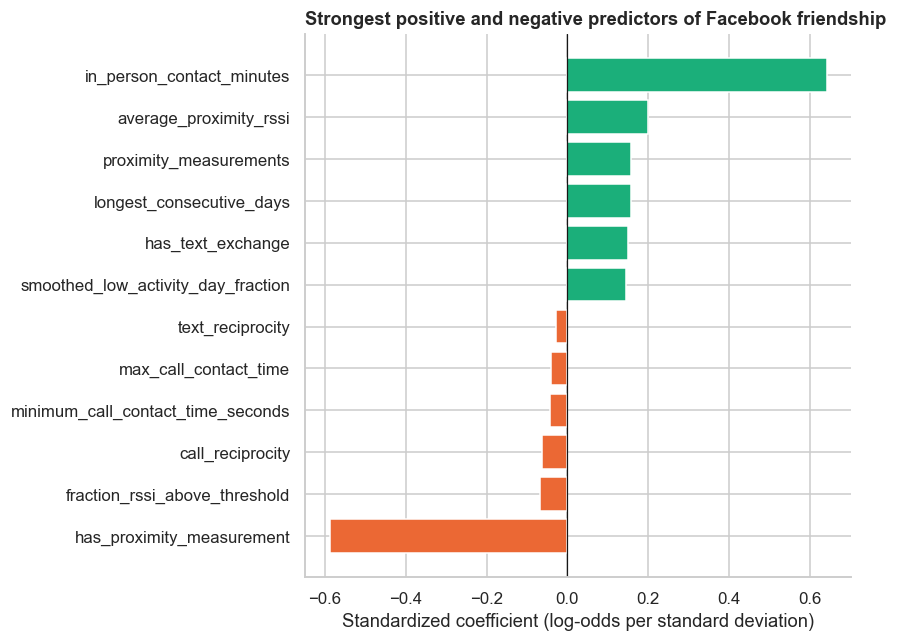

In [10]:
top_n = 12
plot_table = pd.concat([coefficient_table.head(top_n // 2), coefficient_table.tail(top_n // 2)]).drop_duplicates()
plot_table = plot_table.sort_values('Standardized coefficient')

fig, ax = plt.subplots(figsize=(8, 6))
bar_colors = [GREEN if v > 0 else ORANGE for v in plot_table['Standardized coefficient']]
ax.barh(plot_table['Feature'], plot_table['Standardized coefficient'], color=bar_colors)
ax.axvline(0, color=INK, linewidth=0.8)
ax.set_xlabel('Standardized coefficient (log-odds per standard deviation)')
ax.set_title('Strongest positive and negative predictors of Facebook friendship', loc='left', fontweight='bold')
sns.despine(ax=ax)
plt.tight_layout()
save_figure(fig, 'logistic_regression_coefficients.png')
plt.show()

## 7. What this notebook does and doesn't establish

**Established:**
- A leakage-conscious performance number for the human-designed-features arm of the comparison (Section 5), using cross-validation that never lets the same participant appear on both sides of a split.
- A ranked, directionally-interpretable coefficient table (Section 6) that can be set directly against tree-based feature importance / ablation results and against whatever the graph-embedding models surface, to answer *"which forms of interaction best reveal meaningful relationships?"*

**Not established / caveats:**
- **Facebook friendship is an imperfect label.** No Facebook edge doesn't mean two people aren't actually close; a Facebook edge doesn't mean the interaction data captured why.
- **Four weeks is a short window.** Zero observed contact is not necessarily zero real contact.
- **`nn.ipynb`'s current train/test split is a random pair-level split, not participant-disjoint.** For the headline "human-designed vs. learned representations" comparison to be fully apples-to-apples, that notebook's evaluation should be rebuilt on the same `participant_disjoint_folds.csv` partition used here — otherwise the learned-representations arm has an easier evaluation setup than this one, and any performance gap between the two arms is partly a methodology artifact rather than a real difference in feature quality.
- **The coefficient table is a full-data refit, not a cross-validated estimate.** Treat coefficient signs and rough relative sizes as stable; don't over-read three-decimal precision.